<a href="https://colab.research.google.com/github/hoangchaugiahan/FUZZYLOGIC/blob/main/FaceShape.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.layers import Dense,Dropout

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(256, activation='relu', input_shape=(60*60*3,)),
    Dense(128, activation='relu'),
    Dense(generator.num_classes, activation='softmax')
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:

datagen = ImageDataGenerator(rescale=1.0/255)
generator = datagen.flow_from_directory(
    '/content/drive/MyDrive/FACE',
    target_size=(60, 60),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True
)
test_generator = datagen.flow_from_directory(
    '/content/drive/MyDrive/FACE',
    target_size=(60, 60),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=10000,
    shuffle=False
)
class_labels = ['GDRAGON', 'Gia Hân', 'Hải Như', 'ROSE', 'T.O.P']
X_batch, y_batch = next(generator)

Found 71 images belonging to 5 classes.
Found 71 images belonging to 5 classes.


In [ ]:
test_generator = datagen.flow_from_directory(
    '/content/drive/MyDrive/FACE',
    target_size=(60, 60),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=10000,
    shuffle=False
)
x_train, y_train = next(generator)
x_test, y_test = next(test_generator)
x_train = x_train.reshape(x_train.shape[0], 60 * 60 * 3)
x_test = x_test.reshape(x_test.shape[0], 60 * 60 * 3)
print("Train shape:", x_train.shape, y_train.shape)
print("Test shape:", x_test.shape, y_test.shape)


Found 71 images belonging to 5 classes.
Train shape: (32, 10800) (32, 5)
Test shape: (71, 10800) (71, 5)


In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=300, batch_size=32, validation_data=(x_test, y_test))

Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 4.7410e-05 - val_accuracy: 0.7465 - val_loss: 1.5707
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 1.0000 - loss: 6.5692e-05 - val_accuracy: 0.6761 - val_loss: 2.6191
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.9062 - loss: 0.2606 - val_accuracy: 0.6620 - val_loss: 2.4169
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.8750 - loss: 0.5623 - val_accuracy: 0.5915 - val_loss: 2.3302
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.9375 - loss: 0.2768 - val_accuracy: 0.6901 - val_loss: 1.6023
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 1.0000 - loss: 0.0069 - val_accuracy: 0.6479 - val_loss: 2.2714
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.9062 - loss: 0.2454 - val_accuracy: 0.6620 - val_loss: 1.5990
Epoch 8/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.9688 - loss: 0.0536 - val_accuracy: 0.619

In [ ]:
t_loss,test_acc=model.evaluate(x_test,y_test)
print('test_acc:%.2f'%(test_acc*100))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7193 - loss: 1.4923
test_acc:70.42


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Dự đoán: Gia Hân


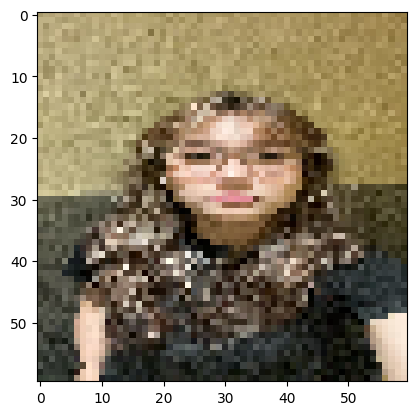

In [ ]:

img = load_img('/content/drive/MyDrive/FACE/Gia Hân/IMG_5216.JPG', target_size=(60, 60))
plt.imshow(img)
img = img_to_array(img)
img_flatten = img.reshape(1, 60 * 60 * 3)
img_flatten = img_flatten.astype('float32') / 255
y_pred_prob = model.predict(img_flatten)
predicted_class_index = int(np.argmax(y_pred_prob))
class_labels = list(generator.class_indices.keys())
print("Dự đoán:", class_labels[predicted_class_index])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Dự đoán: Hải Như


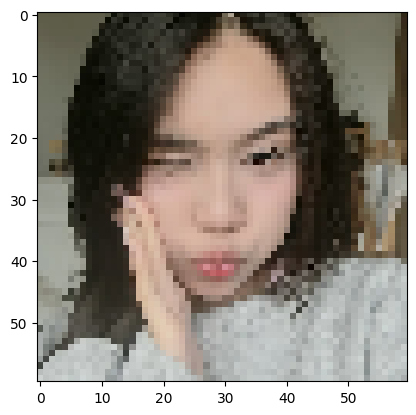

In [ ]:

img = load_img('/content/drive/MyDrive/FACE/Hải Như/att._LrBQWp6JfmtOGSFw-oBBy8MvzgcYHP3cLAW394tTxc.jpg', target_size=(60, 60))
plt.imshow(img)
img = img_to_array(img)
img_flatten = img.reshape(1, 60 * 60 * 3)
img_flatten = img_flatten.astype('float32') / 255
y_pred_prob = model.predict(img_flatten)
predicted_class_index = int(np.argmax(y_pred_prob))
class_labels = list(generator.class_indices.keys())
print("Dự đoán:", class_labels[predicted_class_index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Dự đoán: Gia Hân


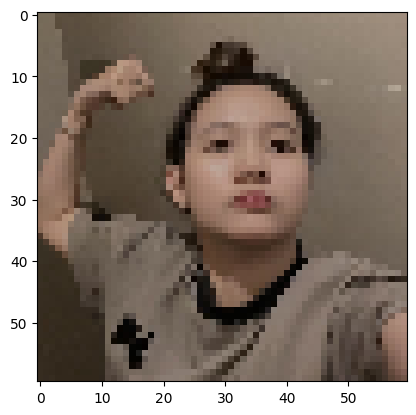

In [ ]:

img = load_img('/content/drive/MyDrive/FACE/Gia Hân/IMG_7955.JPG', target_size=(60, 60))
plt.imshow(img)
img = img_to_array(img)
img_flatten = img.reshape(1, 60 * 60 * 3)
img_flatten = img_flatten.astype('float32') / 255
y_pred_prob = model.predict(img_flatten)
predicted_class_index = int(np.argmax(y_pred_prob))
class_labels = list(generator.class_indices.keys())
print("Dự đoán:", class_labels[predicted_class_index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Dự đoán: T.O.P


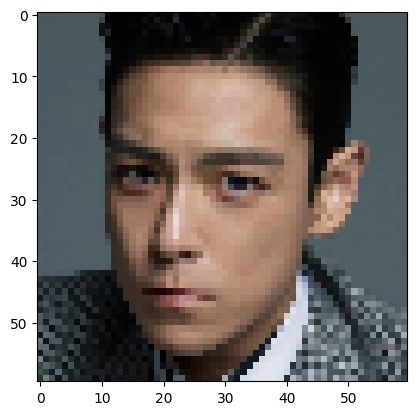

In [ ]:

img = load_img('/content/drive/MyDrive/FACE/T.O.P/IMG_8726.PNG', target_size=(60, 60))
plt.imshow(img)
img = img_to_array(img)
img_flatten = img.reshape(1, 60 * 60 * 3)
img_flatten = img_flatten.astype('float32') / 255
y_pred_prob = model.predict(img_flatten)
predicted_class_index = int(np.argmax(y_pred_prob))
class_labels = list(generator.class_indices.keys())
print("Dự đoán:", class_labels[predicted_class_index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Dự đoán: GDRAGON


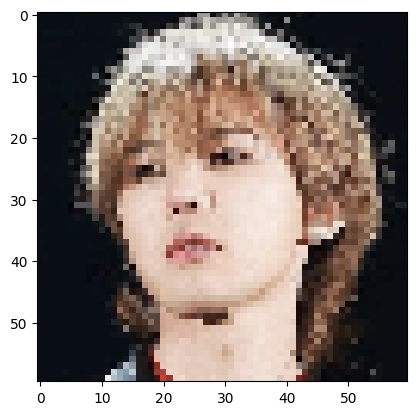

In [ ]:

img = load_img('/content/drive/MyDrive/FACE/GDRAGON/IMG_8721.PNG', target_size=(60, 60))
plt.imshow(img)
img = img_to_array(img)
img_flatten = img.reshape(1, 60 * 60 * 3)
img_flatten = img_flatten.astype('float32') / 255
y_pred_prob = model.predict(img_flatten)
predicted_class_index = int(np.argmax(y_pred_prob))
class_labels = list(generator.class_indices.keys())
print("Dự đoán:", class_labels[predicted_class_index])

In [ ]:
model.save('face.h5')